In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
import math

In [45]:
df = pd.read_csv("./datasets/baby_names.csv", sep=";")

## Data Analysis

In [46]:
display(df.head())
print(df.shape)
print(df.dtypes)

,latin,cyrillic,gender
0,John,Джон,boy
1,William,Уильям,boy
2,James,Джеймс,boy
3,Charles,Чарльз,boy
4,George,Джордж,boy


(6780, 3)
latin       str
cyrillic    str
gender      str
dtype: object


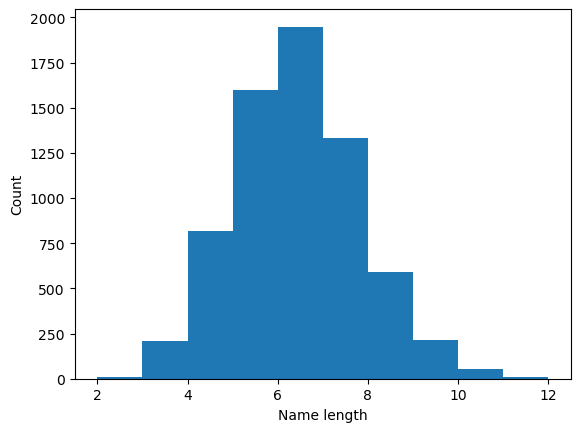

In [47]:
lens_of_name = df.latin.apply(lambda x: len(x))


plt.hist(lens_of_name, bins=range(lens_of_name.min(), lens_of_name.max() + 2))
plt.xlabel("Name length")
plt.ylabel("Count")
plt.show()

In [48]:
gender_values = df.gender.value_counts()

display(gender_values)
display(df["gender"].value_counts(normalize=True))
print(f"\nboy/girl: {gender_values['boy'] / gender_values['girl']}")

gender
boy     3435
girl    3345
Name: count, dtype: int64

gender
boy     0.506637
girl    0.493363
Name: proportion, dtype: float64


boy/girl: 1.0269058295964126


In [49]:
latin_letters = defaultdict(int)
for name in df.latin:
    name = name.lower()
    for s in name:
        latin_letters[s] += 1

In [50]:
latin_letters = dict(sorted(latin_letters.items(), key=lambda x: -x[1]))
latin_letters

{'a': 5592,
 'e': 5037,
 'n': 3519,
 'i': 3264,
 'l': 3255,
 'r': 3070,
 'o': 2070,
 't': 1745,
 's': 1674,
 'd': 1531,
 'm': 1244,
 'y': 1243,
 'h': 1206,
 'c': 1063,
 'u': 705,
 'b': 673,
 'k': 615,
 'g': 526,
 'j': 502,
 'v': 490,
 'f': 302,
 'w': 270,
 'p': 265,
 'z': 199,
 'x': 71,
 'q': 61}

## Data preparation

In [51]:
df_p = df.copy()

# encode gender
df_p["gender"] = (df_p["gender"] == "girl").astype(int)

# lowercase
df_p["latin"] = df_p["latin"].apply(lambda x: x.lower().strip())
df_p["cyrillic"] = df_p["cyrillic"].apply(lambda x: x.lower().strip())

# add SOS and EOS
df_p["latin"] = df_p["latin"].apply(lambda x: ["<SOS>"] + list(x) + ["<EOS>"])
df_p["cyrillic"] = df_p["cyrillic"].apply(lambda x: ["<SOS>"] + list(x) + ["<EOS>"])

max_len_latin = df_p["latin"].apply(len).max()
max_len_cyrillic = df_p["cyrillic"].apply(len).max()

df_p["latin"] = df_p["latin"].apply(lambda x: x + [" "] * (max_len_latin - len(x)))
df_p["cyrillic"] = df_p["cyrillic"].apply(lambda x: x + [" "] * (max_len_cyrillic - len(x)))

In [52]:
df_p

,latin,cyrillic,gender
0,"[<SOS>, j, o, h, n, <EOS>, , , , , , , ]","[<SOS>, д, ж, о, н, <EOS>, , , , , , , ...",0
1,"[<SOS>, w, i, l, l, i, a, m, <EOS>, , , , ]","[<SOS>, у, и, л, ь, я, м, <EOS>, , , , , ...",0
2,"[<SOS>, j, a, m, e, s, <EOS>, , , , , , ]","[<SOS>, д, ж, е, й, м, с, <EOS>, , , , , ...",0
3,"[<SOS>, c, h, a, r, l, e, s, <EOS>, , , , ]","[<SOS>, ч, а, р, л, ь, з, <EOS>, , , , , ...",0
4,"[<SOS>, g, e, o, r, g, e, <EOS>, , , , , ]","[<SOS>, д, ж, о, р, д, ж, <EOS>, , , , , ...",0
...,...,...,...
6775,"[<SOS>, l, a, y, l, a, h, <EOS>, , , , , ]","[<SOS>, л, е, й, л, а, <EOS>, , , , , , ...",1
6776,"[<SOS>, c, a, r, l, e, i, g, h, <EOS>, , , ]","[<SOS>, к, а, р, л, и, <EOS>, , , , , , ...",1
6777,"[<SOS>, k, e, n, l, e, y, <EOS>, , , , , ]","[<SOS>, к, е, н, л, и, <EOS>, , , , , , ...",1
6778,"[<SOS>, s, l, o, a, n, e, <EOS>, , , , , ]","[<SOS>, с, л, о, а, н, <EOS>, , , , , , ...",1


In [53]:
# array of tokens
tokens = sorted(set(token for name in df_p["latin"] for token in name))

token_to_id = {token: i for i, token in enumerate(tokens)}
id_to_token = {i: token for token, i in token_to_id.items()}

print(tokens)
print(token_to_id)
print(id_to_token)

[' ', '<EOS>', '<SOS>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{' ': 0, '<EOS>': 1, '<SOS>': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9, 'h': 10, 'i': 11, 'j': 12, 'k': 13, 'l': 14, 'm': 15, 'n': 16, 'o': 17, 'p': 18, 'q': 19, 'r': 20, 's': 21, 't': 22, 'u': 23, 'v': 24, 'w': 25, 'x': 26, 'y': 27, 'z': 28}
{0: ' ', 1: '<EOS>', 2: '<SOS>', 3: 'a', 4: 'b', 5: 'c', 6: 'd', 7: 'e', 8: 'f', 9: 'g', 10: 'h', 11: 'i', 12: 'j', 13: 'k', 14: 'l', 15: 'm', 16: 'n', 17: 'o', 18: 'p', 19: 'q', 20: 'r', 21: 's', 22: 't', 23: 'u', 24: 'v', 25: 'w', 26: 'x', 27: 'y', 28: 'z'}


In [54]:
df_p = df_p.drop(columns=['cyrillic'])

In [55]:
# name to integer sequences
df_p["encoded_latin"] = df_p["latin"].apply(lambda name: [token_to_id[token] for token in name])

display(df_p)

,latin,gender,encoded_latin
0,"[<SOS>, j, o, h, n, <EOS>, , , , , , , ]",0,"[2, 12, 17, 10, 16, 1, 0, 0, 0, 0, 0, 0, 0]"
1,"[<SOS>, w, i, l, l, i, a, m, <EOS>, , , , ]",0,"[2, 25, 11, 14, 14, 11, 3, 15, 1, 0, 0, 0, 0]"
2,"[<SOS>, j, a, m, e, s, <EOS>, , , , , , ]",0,"[2, 12, 3, 15, 7, 21, 1, 0, 0, 0, 0, 0, 0]"
3,"[<SOS>, c, h, a, r, l, e, s, <EOS>, , , , ]",0,"[2, 5, 10, 3, 20, 14, 7, 21, 1, 0, 0, 0, 0]"
4,"[<SOS>, g, e, o, r, g, e, <EOS>, , , , , ]",0,"[2, 9, 7, 17, 20, 9, 7, 1, 0, 0, 0, 0, 0]"
...,...,...,...
6775,"[<SOS>, l, a, y, l, a, h, <EOS>, , , , , ]",1,"[2, 14, 3, 27, 14, 3, 10, 1, 0, 0, 0, 0, 0]"
6776,"[<SOS>, c, a, r, l, e, i, g, h, <EOS>, , , ]",1,"[2, 5, 3, 20, 14, 7, 11, 9, 10, 1, 0, 0, 0]"
6777,"[<SOS>, k, e, n, l, e, y, <EOS>, , , , , ]",1,"[2, 13, 7, 16, 14, 7, 27, 1, 0, 0, 0, 0, 0]"
6778,"[<SOS>, s, l, o, a, n, e, <EOS>, , , , , ]",1,"[2, 21, 14, 17, 3, 16, 7, 1, 0, 0, 0, 0, 0]"


In [56]:
# train/valid/test
train, temp = train_test_split(df_p, test_size=0.2, random_state=21, stratify=df_p["gender"])
valid, test = train_test_split(temp, test_size=0.5, random_state=21, stratify=temp["gender"])

print(f"train: {len(train)}")
display(train["gender"].value_counts(normalize=True))
print(f"\nvalid: {len(valid)}")
display(valid["gender"].value_counts(normalize=True))
print(f"\ntest:  {len(test)}")
display(test["gender"].value_counts(normalize=True))

train: 5424


gender
0    0.506637
1    0.493363
Name: proportion, dtype: float64


valid: 678


gender
0    0.5059
1    0.4941
Name: proportion, dtype: float64


test:  678


gender
0    0.507375
1    0.492625
Name: proportion, dtype: float64

## Functions

### Models

In [57]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.input_layer = nn.Linear(input_size, hidden_size)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        h = torch.tanh(self.input_layer(x) + self.hidden_layer(h))
        return h

    def init_hidden(self, batch_size, device=None):
        return torch.zeros(batch_size, self.hidden_size, device=device)

In [58]:
class GRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        self.W_ir = nn.Linear(input_size, hidden_size)
        self.W_iz = nn.Linear(input_size, hidden_size)
        self.W_in = nn.Linear(input_size, hidden_size)

        self.W_hr = nn.Linear(hidden_size, hidden_size)
        self.W_hz = nn.Linear(hidden_size, hidden_size)
        self.W_hn = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        r = torch.sigmoid(self.W_ir(x) + self.W_hr(h))
        z = torch.sigmoid(self.W_iz(x) + self.W_hz(h))
        n = torch.tanh(self.W_in(x) + r * self.W_hn(h))
        h_new = (1 - z) * h + z * n
        return h_new

    def init_hidden(self, batch_size, device=None):
        return torch.zeros(batch_size, self.hidden_size, device=device)

In [59]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.W_ii = nn.Linear(input_size, hidden_size)
        self.W_if = nn.Linear(input_size, hidden_size) 
        self.W_io = nn.Linear(input_size, hidden_size)
        self.W_ig = nn.Linear(input_size, hidden_size)

        self.W_hi = nn.Linear(hidden_size, hidden_size)
        self.W_hf = nn.Linear(hidden_size, hidden_size)
        self.W_hg = nn.Linear(hidden_size, hidden_size)
        self.W_ho = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, state):
        h_prev, c_prev = state

        i = torch.sigmoid(self.W_ii(x) + self.W_hi(h_prev))
        f = torch.sigmoid(self.W_if(x) + self.W_hf(h_prev))
        g = torch.tanh(self.W_ig(x) + self.W_hg(h_prev))
        o = torch.sigmoid(self.W_io(x) + self.W_ho(h_prev))

        c_new = f * c_prev + i * g
        h_new = o * torch.tanh(c_new)
                          
        return h_new, c_new

    def init_hidden(self, batch_size, device=None):
        h0 = torch.zeros(batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(batch_size, self.hidden_size, device=device)
        return (h0, c0)

In [60]:
class NameRNN(nn.Module):
    def __init__(self, n_tokens, embedding_size=32, hidden_size=64):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=n_tokens,
            embedding_dim=embedding_size
        )

        self.rnn = VanillaRNN(
            input_size=embedding_size,
            hidden_size=hidden_size
        )

        self.next_token = nn.Linear(
            hidden_size,
            n_tokens
        )

        self.gender = nn.Linear(
            hidden_size,
            1
        )

        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        batch_size, seq_len = x.shape

        embeddings = self.embedding(x)

        h = self.rnn.init_hidden(batch_size, device=x.device)

        outputs = []

        for t in range(seq_len):
            h = self.rnn(embeddings[:, t, :], h)
            outputs.append(h)

        outputs = torch.stack(outputs, dim=1) 
        next_token_logits = self.next_token(self.dropout(outputs))
        gender_logit = self.gender(self.dropout(h))

        return next_token_logits, gender_logit

    def generate(self, start_string="", max_length=10, temperature=1.0, device=None):
        self.eval()
        if device is None:
            device = next(self.parameters()).device

        tokens = [token_to_id["<SOS>"]]
        for ch in start_string.lower():
            if ch in token_to_id:
                tokens.append(token_to_id[ch])
            else:
                raise ValueError(f"Warning: character '{ch}' not in vocabulary, skipping.")

        input_seq = torch.tensor([tokens], dtype=torch.long, device=device)

        mask = torch.ones(self.next_token.out_features, dtype=torch.bool, device=device)
        mask[token_to_id["<SOS>"]] = False
        mask[token_to_id[" "]] = False

        generated = tokens.copy()

        with torch.no_grad():
            for _ in range(max_length):
                next_token_logits, _ = self.forward(input_seq)
                logits = next_token_logits[0, -1, :]

                logits = logits.masked_fill(~mask, float("-inf"))

                if temperature <= 0:
                    next_token = torch.argmax(logits).item()
                else:
                    probs = torch.softmax(logits / temperature, dim=-1)
                    next_token = torch.multinomial(probs, num_samples=1).item()

                generated.append(next_token)

                if next_token == token_to_id["<EOS>"]:
                    break

                input_seq = torch.tensor([generated], dtype=torch.long, device=device)

        result = ''.join([
            id_to_token[idx] for idx in generated
            if idx not in [token_to_id["<SOS>"], token_to_id["<EOS>"], token_to_id[" "]]
        ])
        return result

class GRU_RNN(NameRNN):
    def __init__(self, n_tokens, embedding_size=32, hidden_size=64):
        super().__init__(n_tokens, embedding_size, hidden_size)
        self.rnn = GRUCell(input_size=embedding_size, hidden_size=hidden_size)

class LSTM_RNN(NameRNN):
    def __init__(self, n_tokens, embedding_size=32, hidden_size=64):
        super().__init__(n_tokens, embedding_size, hidden_size)
        self.rnn = LSTMCell(input_size=embedding_size, hidden_size=hidden_size)

    def forward(self, x):
        batch_size, seq_len = x.shape

        embeddings = self.embedding(x)

        h, c = self.rnn.init_hidden(batch_size, device=x.device)

        outputs = []

        for t in range(seq_len):
            h, c = self.rnn(embeddings[:, t, :], (h, c))
            outputs.append(h)

        outputs = torch.stack(outputs, dim=1) 
        next_token_logits = self.next_token(self.dropout(outputs))
        gender_logit = self.gender(self.dropout(h))

        return next_token_logits, gender_logit

### Utils

In [61]:
def next_letter_train_valid_loop(model, optimizer, criterion, train_loader, valid_loader, epochs, n_tokens):
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()

        train_loss = 0

        for (x,) in train_loader:
            optimizer.zero_grad()

            next_token_logits, _ = model(x)
            
            logits = next_token_logits[:, :-1, :]
            targets = x[:, 1:]

            logits = logits.reshape(-1, n_tokens)
            targets = targets.reshape(-1)

            loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()

        valid_loss = 0

        with torch.no_grad():
            for (x,) in valid_loader:
                next_token_logits, _ = model(x)

                logits = next_token_logits[:, :-1, :]
                targets = x[:, 1:]

                logits = logits.reshape(-1, n_tokens)
                targets = targets.reshape(-1)

                loss = criterion(logits, targets)

                valid_loss += loss.item()

        valid_loss /= len(valid_loader)
        valid_losses.append(valid_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"valid loss: {valid_loss:.4f}"
        )

    return train_losses, valid_losses

In [62]:
def losses_graph(train_losses, valid_losses):
    plt.plot(train_losses, label="train")
    plt.plot(valid_losses, label="valid")

    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.show()

In [63]:
def name_generation(model, prefix="an"):
    model.eval()

    # Генерация с разной температурой
    print("Детерминированно (t=0):", model.generate(temperature=0))
    print("Слабая случайность (t=0.5):", model.generate(temperature=0.5))
    print("Стандартная (t=1):", model.generate(temperature=1.0))
    print("Высокая случайность (t=2):", model.generate(temperature=2.0))

    # Генерация с префиксом
    print(f"С префиксом {prefix}:", model.generate(start_string=prefix, temperature=0.8))
    print("10 случайных имен:")
    for i in range(10):
        print(f"{i}: ", model.generate(temperature=1.0))

In [64]:
def freeze_gender_loop(model, train_gender_loader, test_gender_loader, epochs_gender):
    # Замораживаем все параметры модели
    for param in model.parameters():
        param.requires_grad = False

    # Размораживаем только gender-слой
    for param in model.gender.parameters():
        param.requires_grad = True

    criterion_gender = nn.BCEWithLogitsLoss()
    optimizer_gender = torch.optim.Adam(model.gender.parameters(), lr=1e-3)

    model.train()

    for epoch in range(epochs_gender):
        total_loss = 0
        for x_batch, y_batch in train_gender_loader:
            optimizer_gender.zero_grad()
            
            _, gender_logits = model(x_batch)
            loss = criterion_gender(gender_logits.squeeze(), y_batch)
            loss.backward()
            optimizer_gender.step()
            
            total_loss += loss.item()
        print(f"Gender epoch {epoch+1}/{epochs_gender}, loss: {total_loss/len(train_gender_loader):.4f}")

    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in test_gender_loader:
            _, gender_logits = model(x_batch)
            all_logits.append(gender_logits.squeeze().cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())

    # Склеиваем батчи
    all_logits = np.concatenate(all_logits)
    all_labels = np.concatenate(all_labels)

    auc = roc_auc_score(all_labels, all_logits)
    print(f"ROC AUC on test: {auc:.4f}")

    # размораживаем все параметры
    for param in model.parameters():
        param.requires_grad = True

    return auc

In [83]:
def compute_perplexity_with_loss(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for (x,) in data_loader:
            x = x.to(device)
            logits, _ = model(x)
            logits = logits[:, :-1, :]
            targets = x[:, 1:]
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            total_loss += loss.item()          # loss уже сумма (reduction='sum')
            non_pad = (targets != token_to_id[" "]).sum().item()
            total_tokens += non_pad
    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss)

def compute_perplexity_manual(model, data_loader, device):
    """Ручное вычисление перплексии без CrossEntropyLoss."""
    model.eval()
    total_log_prob = 0
    total_tokens = 0
    with torch.no_grad():
        for (x,) in data_loader:
            x = x.to(device)
            logits, _ = model(x)
            logits = logits[:, :-1, :]
            targets = x[:, 1:]
            probs = torch.softmax(logits, dim=-1)    # (batch, seq_len-1, vocab)
            # Собираем вероятности целевых токенов
            batch_size, seq_len_minus1, vocab = probs.shape
            probs = probs.reshape(-1, vocab)
            targets_flat = targets.reshape(-1)
            target_probs = probs[torch.arange(len(targets_flat)), targets_flat]
            # Маска: исключаем пробел
            mask = (targets_flat != token_to_id[" "])
            total_log_prob += torch.log(target_probs[mask]).sum().item()
            total_tokens += mask.sum().item()
    avg_log_prob = total_log_prob / total_tokens
    return math.exp(-avg_log_prob)

In [ ]:
def train_gender_model(model, train_loader, valid_loader, loss_type='BCE', epochs=20, lr=1e-3):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []

    if loss_type == 'BCE':
        criterion = nn.BCEWithLogitsLoss()
    elif loss_type == 'NLL':
        criterion = nn.NLLLoss()
    else:
        raise ValueError("loss_type must be 'BCE' or 'NLL'")

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            _, gender_logit = model(x_batch)
            gender_logit = gender_logit.squeeze()

            if loss_type == 'BCE':
                loss = criterion(gender_logit, y_batch)
            else:
                logits = torch.cat(
                    [torch.zeros_like(gender_logit), gender_logit],
                    dim=1
                )

                log_probs = torch.log_softmax(logits, dim=1)

                loss = nn.NLLLoss()(log_probs, y_batch.long())

            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        valid_loss = 0.0
        for x_batch, y_batch in valid_loader:
            _, gender_logit = model(x_batch)
            gender_logit = gender_logit.squeeze()
    
            if loss_type == 'BCE':
                loss = criterion(gender_logit, y_batch)
            else:
                logits = torch.cat(
                    [torch.zeros_like(gender_logit), gender_logit],
                    dim=1
                )

                log_probs = torch.log_softmax(logits, dim=1)

                loss = nn.NLLLoss()(log_probs, y_batch.long())
            valid_loss += loss.item()

        valid_loss /= len(valid_loader)
        valid_losses.append(valid_loss)

        print(f"Epoch {epoch+1}/{epochs} | train loss: {train_loss:.4f} | valid loss: {valid_loss:.4f}")
    
    return train_losses, valid_losses

In [119]:
def collect_gradients(model, data_loader, epochs, loss_type='gender', lr=1e-3):
    """
    Обучает модель и собирает градиенты по выходу embedding-слоя.
    Возвращает тензор (n_epochs, max_len, n_tokens, embedding_size).
    """
    device = next(model.parameters()).device
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if loss_type == 'gender':
        criterion = nn.BCEWithLogitsLoss()
    elif loss_type == 'next_token':
        criterion = nn.CrossEntropyLoss(ignore_index=token_to_id[" "])
    else:
        raise ValueError("loss_type must be 'gender' or 'next_token'")

    # Определяем max_len из первого батча
    first_batch = next(iter(data_loader))
    if isinstance(first_batch, (list, tuple)):
        max_len = first_batch[0].shape[1]
    else:
        max_len = first_batch.shape[1]

    n_tokens = len(tokens)
    emb_size = model.embedding.embedding_dim

    epoch_grads = []
    current_batch_grads = None

    def backward_hook(module, grad_input, grad_output):
        nonlocal current_batch_grads
        current_batch_grads = grad_output[0].detach().cpu()  # (batch, seq_len, emb_size)

    handle = model.embedding.register_full_backward_hook(backward_hook)

    for epoch in range(epochs):
        epoch_sum = torch.zeros(max_len, n_tokens, emb_size)
        epoch_count = 0

        for batch in data_loader:
            # Универсальная обработка батча (может быть с y или без)
            if isinstance(batch, (list, tuple)):
                x_batch = batch[0].to(device)
                y_batch = batch[1].to(device) if len(batch) > 1 else None
            else:
                x_batch = batch.to(device)
                y_batch = None

            optimizer.zero_grad()

            # Прямой проход
            next_token_logits, gender_logit = model(x_batch)

            # Вычисление потерь
            if loss_type == 'gender':
                # Исправляем размерности: оба тензора (batch_size,)
                loss = criterion(gender_logit.view(-1), y_batch.view(-1))
            else:  # next_token
                logits = next_token_logits[:, :-1, :]
                targets = x_batch[:, 1:]
                loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

            loss.backward()
            optimizer.step()

            # Собираем градиенты по выходу embedding для каждого примера и позиции
            batch_size = x_batch.size(0)
            for b in range(batch_size):
                input_ids = x_batch[b].cpu()
                grad_output_b = current_batch_grads[b]  # (seq_len, emb_size)
                for t in range(max_len):
                    token_id = input_ids[t].item()
                    epoch_sum[t, token_id] += grad_output_b[t]
                epoch_count += 1

        epoch_avg = epoch_sum / epoch_count
        epoch_grads.append(epoch_avg)

    handle.remove()
    return torch.stack(epoch_grads)

In [115]:
def frobenius_norms_per_position(epoch_grads):
    """
    Вход: (n_epochs, max_len, n_tokens, emb_size)
    Выход: (n_epochs, max_len) – Frobenius norm матрицы (n_tokens x emb_size) для каждой позиции.
    """
    n_epochs, max_len, n_tokens, emb_size = epoch_grads.shape
    norms = torch.empty(n_epochs, max_len)
    for e in range(n_epochs):
        for t in range(max_len):
            # Матрица градиентов для позиции t и эпохи e
            mat = epoch_grads[e, t, :, :]  # (n_tokens, emb_size)
            norms[e, t] = torch.norm(mat, p='fro')
    return norms

In [ ]:
def mean_frobenius_norm(epoch_grads):
    """Возвращает (max_len,) – средняя по эпохам Frobenius-норма."""
    norms = frobenius_norms_per_position(epoch_grads)
    return norms.mean(dim=0)

## Datasets & dataloaders

In [88]:
X_train = torch.tensor(train["encoded_latin"].tolist(), dtype=torch.long)
X_valid = torch.tensor(valid["encoded_latin"].tolist(), dtype=torch.long)
X_test = torch.tensor(test["encoded_latin"].tolist(), dtype=torch.long)

y_train = torch.tensor(train["gender"].tolist(), dtype=torch.float32)
y_valid = torch.tensor(valid["gender"].tolist(), dtype=torch.float32)
y_test  = torch.tensor(test["gender"].tolist(), dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train), batch_size=128, shuffle=True)
valid_loader = DataLoader(TensorDataset(X_valid), batch_size=128)
test_loader = DataLoader(TensorDataset(X_test), batch_size=128)

train_gender_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
valid_gender_loader = DataLoader(TensorDataset(X_valid, y_valid), batch_size=128, shuffle=False)
test_gender_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=128, shuffle=False)

## Vanila RNN

In [67]:
n_tokens = len(tokens)

model_vanilla = NameRNN(
    n_tokens=n_tokens,
    embedding_size=32,
    hidden_size=128
)

criterion = nn.CrossEntropyLoss(ignore_index=token_to_id[" "])
optimizer = torch.optim.Adam(model_vanilla.parameters(), lr=1e-3)

Epoch 1/20 | train loss: 2.8384 | valid loss: 2.4877
Epoch 2/20 | train loss: 2.4621 | valid loss: 2.3491
Epoch 3/20 | train loss: 2.3718 | valid loss: 2.2850
Epoch 4/20 | train loss: 2.3242 | valid loss: 2.2454
Epoch 5/20 | train loss: 2.2903 | valid loss: 2.2210
Epoch 6/20 | train loss: 2.2713 | valid loss: 2.2047
Epoch 7/20 | train loss: 2.2527 | valid loss: 2.1880
Epoch 8/20 | train loss: 2.2382 | valid loss: 2.1780
Epoch 9/20 | train loss: 2.2252 | valid loss: 2.1710
Epoch 10/20 | train loss: 2.2234 | valid loss: 2.1596
Epoch 11/20 | train loss: 2.2115 | valid loss: 2.1527
Epoch 12/20 | train loss: 2.2006 | valid loss: 2.1410
Epoch 13/20 | train loss: 2.1940 | valid loss: 2.1355
Epoch 14/20 | train loss: 2.1885 | valid loss: 2.1353
Epoch 15/20 | train loss: 2.1816 | valid loss: 2.1294
Epoch 16/20 | train loss: 2.1818 | valid loss: 2.1242
Epoch 17/20 | train loss: 2.1717 | valid loss: 2.1204
Epoch 18/20 | train loss: 2.1655 | valid loss: 2.1132
Epoch 19/20 | train loss: 2.1629 | va

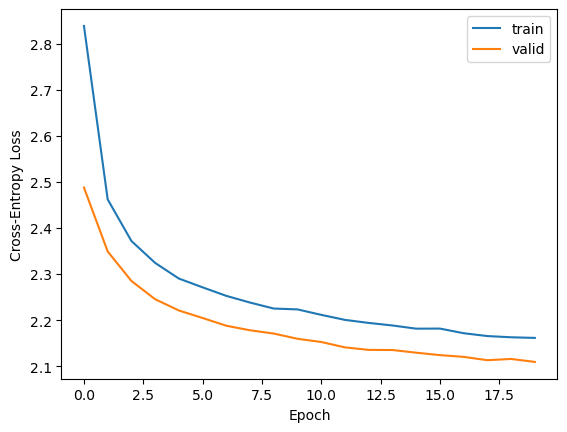

In [68]:
train_losses, valid_losses = next_letter_train_valid_loop(
    model=model_vanilla,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    valid_loader=valid_loader,
    epochs=20,
    n_tokens=n_tokens
)

losses_graph(train_losses, valid_losses)

In [69]:
name_generation(model_vanilla, "an")

Детерминированно (t=0): alisa
Слабая случайность (t=0.5): marisan
Стандартная (t=1): ilahalice
Высокая случайность (t=2): yhcluwgatb


С префиксом an: ancel
10 случайных имен:
0:  jabe
1:  toleel
2:  rynija
3:  deriston
4:  assino
5:  merce
6:  keya
7:  alma
8:  hart
9:  bude


In [70]:
freeze_gender_loop(
    model=model_vanilla,
    train_gender_loader=train_gender_loader,
    test_gender_loader=test_gender_loader,
    epochs_gender=10
)

Gender epoch 1/10, loss: 0.7102
Gender epoch 2/10, loss: 0.7043
Gender epoch 3/10, loss: 0.6999
Gender epoch 4/10, loss: 0.6932
Gender epoch 5/10, loss: 0.6927
Gender epoch 6/10, loss: 0.6931
Gender epoch 7/10, loss: 0.6884
Gender epoch 8/10, loss: 0.6864
Gender epoch 9/10, loss: 0.6844
Gender epoch 10/10, loss: 0.6840
ROC AUC on test: 0.6428


0.6428422225316808

## GRU

In [71]:
n_tokens = len(tokens)

model_gru = GRU_RNN(
    n_tokens=n_tokens,
    embedding_size=32,
    hidden_size=128
)

criterion = nn.CrossEntropyLoss(ignore_index=token_to_id[" "])
optimizer = torch.optim.Adam(model_gru.parameters(), lr=1e-3)

Epoch 1/20 | train loss: 2.8907 | valid loss: 2.5356
Epoch 2/20 | train loss: 2.4770 | valid loss: 2.3597
Epoch 3/20 | train loss: 2.3684 | valid loss: 2.2819
Epoch 4/20 | train loss: 2.3066 | valid loss: 2.2346
Epoch 5/20 | train loss: 2.2670 | valid loss: 2.2000
Epoch 6/20 | train loss: 2.2377 | valid loss: 2.1791
Epoch 7/20 | train loss: 2.2216 | valid loss: 2.1614
Epoch 8/20 | train loss: 2.2030 | valid loss: 2.1464
Epoch 9/20 | train loss: 2.1832 | valid loss: 2.1341
Epoch 10/20 | train loss: 2.1714 | valid loss: 2.1234
Epoch 11/20 | train loss: 2.1634 | valid loss: 2.1121
Epoch 12/20 | train loss: 2.1510 | valid loss: 2.1040
Epoch 13/20 | train loss: 2.1402 | valid loss: 2.0928
Epoch 14/20 | train loss: 2.1256 | valid loss: 2.0863
Epoch 15/20 | train loss: 2.1181 | valid loss: 2.0796
Epoch 16/20 | train loss: 2.1153 | valid loss: 2.0719
Epoch 17/20 | train loss: 2.1026 | valid loss: 2.0684
Epoch 18/20 | train loss: 2.0991 | valid loss: 2.0678
Epoch 19/20 | train loss: 2.0867 | va

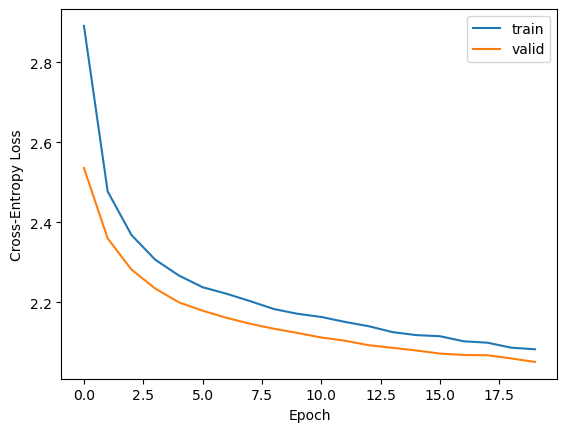

In [72]:
train_losses, valid_losses = next_letter_train_valid_loop(
    model=model_gru,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    valid_loader=valid_loader,
    epochs=20,
    n_tokens=n_tokens
)

losses_graph(train_losses, valid_losses)

In [73]:
name_generation(model_gru, "an")

Детерминированно (t=0): alisa
Слабая случайность (t=0.5): etila
Стандартная (t=1): bekaner
Высокая случайность (t=2): ldaas
С префиксом an: anda
10 случайных имен:
0:  artah
1:  jarian
2:  korn
3:  corda
4:  mancin
5:  calanis
6:  olzolme
7:  tishun
8:  miliel
9:  mekaros


In [74]:
freeze_gender_loop(
    model=model_gru,
    train_gender_loader=train_gender_loader,
    test_gender_loader=test_gender_loader,
    epochs_gender=10
)

Gender epoch 1/10, loss: 0.7067
Gender epoch 2/10, loss: 0.7036
Gender epoch 3/10, loss: 0.6983
Gender epoch 4/10, loss: 0.6932
Gender epoch 5/10, loss: 0.6910
Gender epoch 6/10, loss: 0.6857
Gender epoch 7/10, loss: 0.6815
Gender epoch 8/10, loss: 0.6825
Gender epoch 9/10, loss: 0.6787
Gender epoch 10/10, loss: 0.6794
ROC AUC on test: 0.6732


0.673165297312352

## LSTM

In [75]:
n_tokens = len(tokens)

model_lstm = LSTM_RNN(
    n_tokens=n_tokens,
    embedding_size=32,
    hidden_size=128
)

criterion = nn.CrossEntropyLoss(ignore_index=token_to_id[" "])
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

Epoch 1/20 | train loss: 2.9712 | valid loss: 2.6336
Epoch 2/20 | train loss: 2.5573 | valid loss: 2.4472
Epoch 3/20 | train loss: 2.4178 | valid loss: 2.3364
Epoch 4/20 | train loss: 2.3408 | valid loss: 2.2774
Epoch 5/20 | train loss: 2.3015 | valid loss: 2.2410
Epoch 6/20 | train loss: 2.2695 | valid loss: 2.2155
Epoch 7/20 | train loss: 2.2486 | valid loss: 2.1927
Epoch 8/20 | train loss: 2.2293 | valid loss: 2.1773
Epoch 9/20 | train loss: 2.2092 | valid loss: 2.1585
Epoch 10/20 | train loss: 2.1922 | valid loss: 2.1436
Epoch 11/20 | train loss: 2.1773 | valid loss: 2.1314
Epoch 12/20 | train loss: 2.1687 | valid loss: 2.1207
Epoch 13/20 | train loss: 2.1530 | valid loss: 2.1110
Epoch 14/20 | train loss: 2.1442 | valid loss: 2.0996
Epoch 15/20 | train loss: 2.1363 | valid loss: 2.0948
Epoch 16/20 | train loss: 2.1239 | valid loss: 2.0867
Epoch 17/20 | train loss: 2.1166 | valid loss: 2.0761
Epoch 18/20 | train loss: 2.1070 | valid loss: 2.0714
Epoch 19/20 | train loss: 2.1026 | va

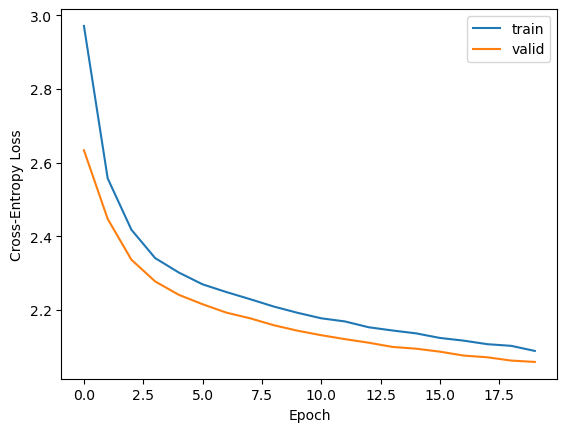

In [76]:
train_losses, valid_losses = next_letter_train_valid_loop(
    model=model_lstm,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    valid_loader=valid_loader,
    epochs=20,
    n_tokens=n_tokens
)

losses_graph(train_losses, valid_losses)

In [77]:
name_generation(model_lstm, "an")

Детерминированно (t=0): alisa
Слабая случайность (t=0.5): are
Стандартная (t=1): siz
Высокая случайность (t=2): kifkdodw
С префиксом an: anrone
10 случайных имен:
0:  cristed
1:  nramina
2:  remelah
3:  bewya
4:  horrettan
5:  elonoy
6:  henettie
7:  kayli
8:  jenna
9:  dotshy


In [78]:
freeze_gender_loop(
    model=model_lstm,
    train_gender_loader=train_gender_loader,
    test_gender_loader=test_gender_loader,
    epochs_gender=10
)

Gender epoch 1/10, loss: 0.6982
Gender epoch 2/10, loss: 0.6830
Gender epoch 3/10, loss: 0.6808
Gender epoch 4/10, loss: 0.6785
Gender epoch 5/10, loss: 0.6757
Gender epoch 6/10, loss: 0.6699
Gender epoch 7/10, loss: 0.6695
Gender epoch 8/10, loss: 0.6675
Gender epoch 9/10, loss: 0.6674
Gender epoch 10/10, loss: 0.6636
ROC AUC on test: 0.6558


0.6558365826486562

## Perplexity

### Random model

In [79]:
V = len(tokens)
ppl_random = V
print(f"Размер словаря: {V}, перплексия случайной модели: {ppl_random}")

Размер словаря: 29, перплексия случайной модели: 29


### Most popular letters model

In [80]:
from collections import Counter

# Собираем все буквы из обучающих имён (без служебных токенов)
letter_counter = Counter()
for name_tokens in train["latin"]:
    for tok in name_tokens:
        if tok not in ["<SOS>", "<EOS>", " "]:
            letter_counter[tok] += 1

total_letters = sum(letter_counter.values())
letter_probs = {ch: count / total_letters for ch, count in letter_counter.items()}

# Функция для вычисления перплексии модели частот
def perplexity_frequency_model(data_loader, probs):
    total_log_prob = 0
    total_tokens = 0
    with torch.no_grad():
        for (x,) in data_loader:
            for seq in x:
                # seq – тензор индексов, длина max_len
                # нам нужны целевые токены, начиная с индекса 1
                targets = seq[1:].tolist()
                for idx in targets:
                    tok = id_to_token[idx]
                    if tok in probs:  # только буквы
                        total_log_prob += math.log(probs[tok])
                        total_tokens += 1
    avg_log_prob = total_log_prob / total_tokens
    return math.exp(-avg_log_prob)

In [81]:
test_loader = DataLoader(TensorDataset(X_test), batch_size=128)
ppl_freq = perplexity_frequency_model(test_loader, letter_probs)
print(f"Перплексия модели частот букв: {ppl_freq:.2f}")

Перплексия модели частот букв: 17.06


### Compare the models

In [84]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion_eval = nn.CrossEntropyLoss(ignore_index=token_to_id[" "], reduction='sum')

# Функция для удобства
def get_ppl(model, loader):
    model.to(device)
    return compute_perplexity_with_loss(model, loader, criterion_eval, device)

test_loader = DataLoader(TensorDataset(X_test), batch_size=128)

ppl_vanilla = get_ppl(model_vanilla, test_loader)
ppl_gru = get_ppl(model_gru, test_loader)
ppl_lstm = get_ppl(model_lstm, test_loader)

print(f"Perplexity Random: {ppl_random}")
print(f"Perplexity Frequency: {ppl_freq:.2f}")
print(f"Perplexity Vanilla RNN: {ppl_vanilla:.2f}")
print(f"Perplexity GRU: {ppl_gru:.2f}")
print(f"Perplexity LSTM: {ppl_lstm:.2f}")

Perplexity Random: 29
Perplexity Frequency: 17.06
Perplexity Vanilla RNN: 8.32
Perplexity GRU: 7.91
Perplexity LSTM: 7.97


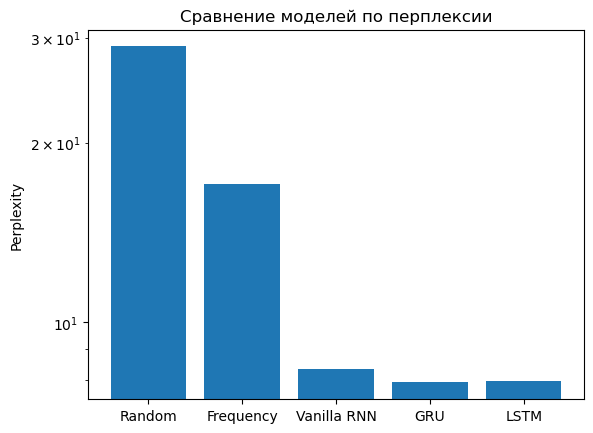

In [85]:
models = ['Random', 'Frequency', 'Vanilla RNN', 'GRU', 'LSTM']
values = [ppl_random, ppl_freq, ppl_vanilla, ppl_gru, ppl_lstm]

plt.bar(models, values)
plt.ylabel('Perplexity')
plt.yscale('log')  # из-за больших различий
plt.title('Сравнение моделей по перплексии')
plt.show()

## Gender classification

In [91]:
results = {}

for arch_name, model_class in [('RNN', NameRNN), ('GRU', GRU_RNN), ('LSTM', LSTM_RNN)]:
    for loss_type in ['BCE', 'NLL']:
        print(f"\n=== {arch_name} with {loss_type} loss ===")
        model = model_class(n_tokens=n_tokens, embedding_size=32, hidden_size=64)
        train_losses, valid_losses = train_gender_model(
            model, train_gender_loader, valid_gender_loader, loss_type=loss_type, epochs=20
        )
        # Оценка AUC на тесте
        model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for x_batch, y_batch in test_gender_loader:
                _, gender_logit = model(x_batch)
                all_logits.append(gender_logit.squeeze().cpu().numpy())
                all_labels.append(y_batch.cpu().numpy())
        all_logits = np.concatenate(all_logits)
        all_labels = np.concatenate(all_labels)
        auc = roc_auc_score(all_labels, all_logits)
        results[(arch_name, loss_type)] = (train_losses, valid_losses, model, auc)
        print(f"ROC AUC = {auc:.4f}")


=== RNN with BCE loss ===
Epoch 1/20 | train loss: 0.6978 | valid loss: 0.6778
Epoch 2/20 | train loss: 0.6077 | valid loss: 0.5239
Epoch 3/20 | train loss: 0.5089 | valid loss: 0.4526
Epoch 4/20 | train loss: 0.4595 | valid loss: 0.4945
Epoch 5/20 | train loss: 0.4461 | valid loss: 0.4803
Epoch 6/20 | train loss: 0.4422 | valid loss: 0.4099
Epoch 7/20 | train loss: 0.4340 | valid loss: 0.4065
Epoch 8/20 | train loss: 0.4232 | valid loss: 0.4206
Epoch 9/20 | train loss: 0.4200 | valid loss: 0.4057
Epoch 10/20 | train loss: 0.4131 | valid loss: 0.4108
Epoch 11/20 | train loss: 0.4075 | valid loss: 0.3813
Epoch 12/20 | train loss: 0.4051 | valid loss: 0.3857
Epoch 13/20 | train loss: 0.3961 | valid loss: 0.3854
Epoch 14/20 | train loss: 0.3861 | valid loss: 0.4151
Epoch 15/20 | train loss: 0.3837 | valid loss: 0.3891
Epoch 16/20 | train loss: 0.3750 | valid loss: 0.3757
Epoch 17/20 | train loss: 0.3722 | valid loss: 0.3803
Epoch 18/20 | train loss: 0.3717 | valid loss: 0.3956
Epoch 19/2

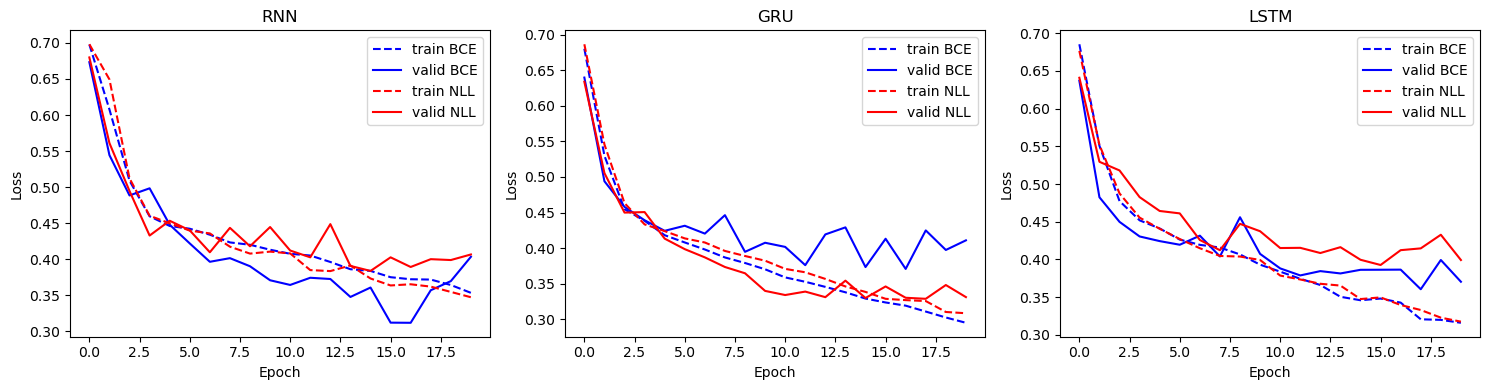

In [93]:
def to_numpy_list(lst):
    return [l.item() if torch.is_tensor(l) else l for l in lst]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
archs = ['RNN', 'GRU', 'LSTM']

for i, arch in enumerate(archs):
    ax = axes[i]
    for loss_type, color in [('BCE', 'blue'), ('NLL', 'red')]:
        train_losses, valid_losses, _, _ = results[(arch, loss_type)]
        train_losses = to_numpy_list(train_losses)
        valid_losses = to_numpy_list(valid_losses)
        ax.plot(train_losses, label=f'train {loss_type}', color=color, linestyle='--')
        ax.plot(valid_losses, label=f'valid {loss_type}', color=color)
    ax.set_title(arch)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()

In [94]:
for arch in archs:
    print(f"\n--- {arch} (BCE) ---")
    model_bce = results[(arch, 'BCE')][2]
    model_bce.eval()
    for _ in range(10):
        print(model_bce.generate(temperature=1.0))
    print(f"\n--- {arch} (NLL) ---")
    model_nll = results[(arch, 'NLL')][2]
    model_nll.eval()
    for _ in range(10):
        print(model_nll.generate(temperature=1.0))


--- RNN (BCE) ---
cnxjhpaxrf
tlivsqgnjn
uwwp
sjklbkckkn
glnb
bgo
we
gqyrxdbogg
colaucfup
czwciyrzif

--- RNN (NLL) ---
ybhwchamxn
vwefllpbh
qoqkgpdurx
xgul
juoxseqktd
saee
elyyvpkzsa
uvasjhqtgg
uljfiwg
fhzcfmzvew

--- GRU (BCE) ---
ssefdwfjhw
a
lftvifvzzg
khg
sttb
ogod
akjcbkycrp
sjglwvxklw
qhtvysmzhu
ynadobujfu

--- GRU (NLL) ---
nb
lvdzddxwfl
xwdzppsebv

lntkfbnwut
owlzkttpbu
wlsznnemzd
hqgleglera
ijmtgiqcda
undxgijajg

--- LSTM (BCE) ---
lkkqydizet

ncluo
vjfwn
tfdaegyglv
qjvxtfybgc
tvbekntfhf
cxn
zquzztiyyj
pxprlggzwc

--- LSTM (NLL) ---
suxgpgbtvn
jpzity
osjjwvroyo
rbzisxvvqz
ewjbmwlakk
mudafjoplp
ynhvjlvuqs
bbueujwgut
umvqlxwcdr
lccsxzdmsl


Видно, что модель, обученная на предсказание гендера плохо генерирует сами имена (получается просто набор букв).

In [95]:
for arch in archs:
    for loss_type in ['BCE', 'NLL']:
        auc = results[(arch, loss_type)][3]
        print(f"{arch} + {loss_type}: AUC = {auc:.4f}")

RNN + BCE: AUC = 0.8984
RNN + NLL: AUC = 0.9076
GRU + BCE: AUC = 0.9068
GRU + NLL: AUC = 0.9059
LSTM + BCE: AUC = 0.9013
LSTM + NLL: AUC = 0.9074


## Vanishing gradient

In [125]:
train_name_lengths = train["latin"].apply(
    lambda x: len([tok for tok in x if tok not in ["<SOS>", "<EOS>", " "]])
)
mode_length = train_name_lengths.mode()[0]
print(f"Мода длины имени: {mode_length}")

train_fixed = train[train_name_lengths == mode_length].reset_index(drop=True)
print(f"Размер подмножества: {len(train_fixed)}")

X_train_fixed = torch.tensor(train_fixed["encoded_latin"].tolist(), dtype=torch.long)
y_train_fixed = torch.tensor(train_fixed["gender"].tolist(), dtype=torch.float32)

train_fixed_loader = DataLoader(TensorDataset(X_train_fixed), batch_size=128, shuffle=True)
train_gender_fixed_loader = DataLoader(TensorDataset(X_train_fixed, y_train_fixed), batch_size=128, shuffle=True)

Мода длины имени: 6
Размер подмножества: 1577


In [126]:
debug_loader = DataLoader(TensorDataset(X_train_fixed, y_train_fixed), batch_size=1, shuffle=True)
debug_model = NameRNN(n_tokens=len(tokens), embedding_size=32, hidden_size=64)
debug_grads = collect_gradients(debug_model, debug_loader, epochs=1, loss_type='gender')

grad_norms = torch.norm(debug_grads[0], dim=-1)  # (max_len, n_tokens)
x_example, _ = next(iter(debug_loader))
print("Токены примера:", [id_to_token[idx] for idx in x_example[0].tolist()])

for t in range(grad_norms.shape[0]):
    nonzero = [id_to_token[i] for i in range(grad_norms.shape[1]) if grad_norms[t, i] > 1e-6]
    print(f"Позиция {t}: {nonzero}")

Токены примера: ['<SOS>', 'a', 'l', 'c', 'i', 'd', 'e', '<EOS>', ' ', ' ', ' ', ' ', ' ']
Позиция 0: ['<SOS>']
Позиция 1: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z']
Позиция 2: ['a', 'b', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z']
Позиция 3: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Позиция 4: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Позиция 5: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y', 'z']
Позиция 6: ['a', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'v', 'w', 'y', 'z']
Позиция 7: ['<EOS>']
Позиция 8: [' ']
Позиция 9: [' ']
Позиция 10: [' ']
Позиция 11: [' ']
Позиция 12:

Обучение RNN (gender)...
Обучение GRU (gender)...
Обучение LSTM (gender)...


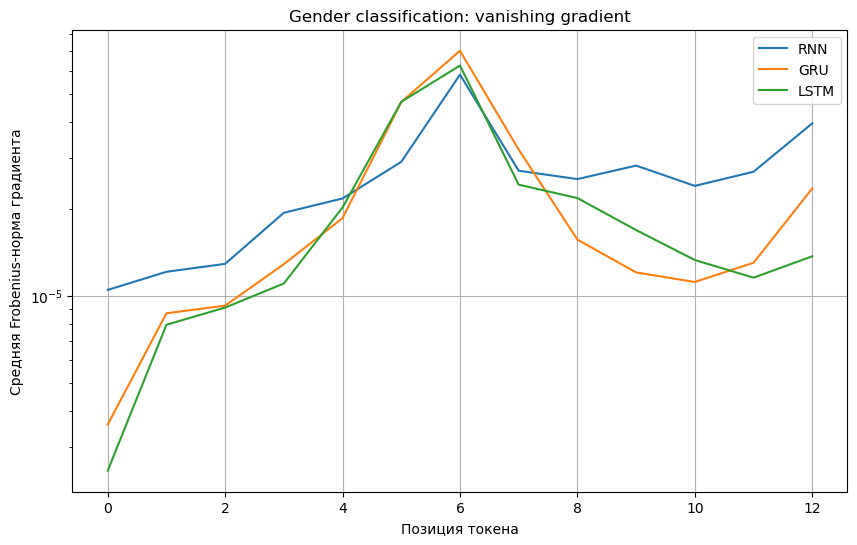

In [127]:
epochs = 10
models_gender, grads_gender = {}, {}
for arch_name, model_class in [('RNN', NameRNN), ('GRU', GRU_RNN), ('LSTM', LSTM_RNN)]:
    print(f"Обучение {arch_name} (gender)...")
    model = model_class(n_tokens=len(tokens), embedding_size=32, hidden_size=64)
    grads = collect_gradients(model, train_gender_fixed_loader, epochs=epochs, loss_type='gender')
    models_gender[arch_name] = model
    grads_gender[arch_name] = grads

# График
plt.figure(figsize=(10,6))
for arch in ['RNN','GRU','LSTM']:
    mean_norm = mean_frobenius_norm(grads_gender[arch])
    plt.plot(range(len(mean_norm)), mean_norm.numpy(), label=arch)
plt.xlabel('Позиция токена')
plt.ylabel('Средняя Frobenius-норма градиента')
plt.title('Gender classification: vanishing gradient')
plt.legend()
plt.grid()
plt.yscale('log')
plt.show()

Обучение RNN (next_token)...
Обучение GRU (next_token)...
Обучение LSTM (next_token)...


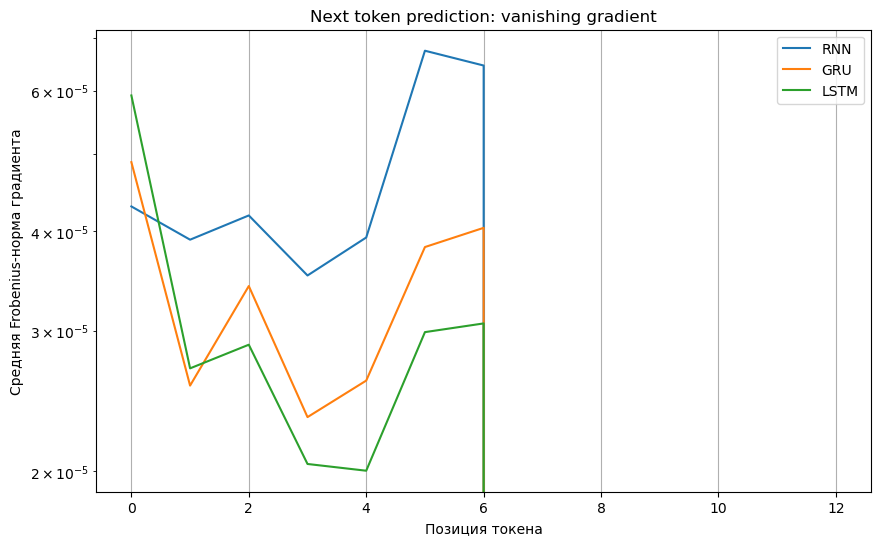

In [128]:
models_next, grads_next = {}, {}
for arch_name, model_class in [('RNN', NameRNN), ('GRU', GRU_RNN), ('LSTM', LSTM_RNN)]:
    print(f"Обучение {arch_name} (next_token)...")
    model = model_class(n_tokens=len(tokens), embedding_size=32, hidden_size=64)
    grads = collect_gradients(model, train_fixed_loader, epochs=epochs, loss_type='next_token')
    models_next[arch_name] = model
    grads_next[arch_name] = grads

plt.figure(figsize=(10,6))
for arch in ['RNN','GRU','LSTM']:
    mean_norm = mean_frobenius_norm(grads_next[arch])
    plt.plot(range(len(mean_norm)), mean_norm.numpy(), label=arch)
plt.xlabel('Позиция токена')
plt.ylabel('Средняя Frobenius-норма градиента')
plt.title('Next token prediction: vanishing gradient')
plt.legend()
plt.grid()
plt.yscale('log')
plt.show()

In [130]:
for task_name, grads_dict in [('gender', grads_gender), ('next_token', grads_next)]:
    print(f"\n--- {task_name} ---")
    for arch in ['RNN', 'GRU', 'LSTM']:
        mean_norm = mean_frobenius_norm(grads_dict[arch])
        first_pos = mean_norm[1].item()
        last_pos = mean_norm[6].item()
        ratio = first_pos / last_pos if last_pos != 0 else float('inf')
        print(f"{arch}: norm(pos1)={first_pos:.2e}, norm(pos6)={last_pos:.2e}, ratio pos1/pos6 = {ratio:.4f}")


--- gender ---
RNN: norm(pos1)=1.21e-05, norm(pos6)=5.82e-05, ratio pos1/pos6 = 0.2085
GRU: norm(pos1)=8.72e-06, norm(pos6)=7.03e-05, ratio pos1/pos6 = 0.1240
LSTM: norm(pos1)=7.96e-06, norm(pos6)=6.25e-05, ratio pos1/pos6 = 0.1274

--- next_token ---
RNN: norm(pos1)=3.91e-05, norm(pos6)=6.46e-05, ratio pos1/pos6 = 0.6046
GRU: norm(pos1)=2.56e-05, norm(pos6)=4.04e-05, ratio pos1/pos6 = 0.6339
LSTM: norm(pos1)=2.69e-05, norm(pos6)=3.07e-05, ratio pos1/pos6 = 0.8783


## Multitask learning

In [131]:
# Multitask Learning with GRU
model_multitask = GRU_RNN(n_tokens=len(tokens), embedding_size=32, hidden_size=64)

criterion_next = nn.CrossEntropyLoss(ignore_index=token_to_id[" "])
criterion_gender = nn.BCEWithLogitsLoss()
optimizer_multitask = torch.optim.Adam(model_multitask.parameters(), lr=1e-3)

epochs = 20
train_losses_next, valid_losses_next = [], []
train_losses_gender, valid_losses_gender = [], []

for epoch in range(epochs):
    model_multitask.train()
    train_loss_next_sum, train_loss_gender_sum = 0.0, 0.0

    for x_batch, y_batch in train_gender_loader:
        optimizer_multitask.zero_grad()

        next_logits, gender_logit = model_multitask(x_batch)

        # Потеря для следующей буквы
        logits = next_logits[:, :-1, :]
        targets = x_batch[:, 1:]
        loss_next = criterion_next(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1)
        )

        # Потеря для пола
        loss_gender = criterion_gender(
            gender_logit.view(-1),
            y_batch.view(-1)
        )

        loss = loss_next + loss_gender   # можно добавить весовой коэффициент
        loss.backward()
        optimizer_multitask.step()

        train_loss_next_sum += loss_next.item()
        train_loss_gender_sum += loss_gender.item()

    train_losses_next.append(train_loss_next_sum / len(train_gender_loader))
    train_losses_gender.append(train_loss_gender_sum / len(train_gender_loader))

    # Валидация
    model_multitask.eval()
    valid_loss_next_sum, valid_loss_gender_sum = 0.0, 0.0
    with torch.no_grad():
        for x_batch, y_batch in valid_gender_loader:
            next_logits, gender_logit = model_multitask(x_batch)

            logits = next_logits[:, :-1, :]
            targets = x_batch[:, 1:]
            loss_next = criterion_next(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1)
            )
            loss_gender = criterion_gender(
                gender_logit.view(-1),
                y_batch.view(-1)
            )

            valid_loss_next_sum += loss_next.item()
            valid_loss_gender_sum += loss_gender.item()

    valid_losses_next.append(valid_loss_next_sum / len(valid_gender_loader))
    valid_losses_gender.append(valid_loss_gender_sum / len(valid_gender_loader))

    print(f"Epoch {epoch+1}/{epochs} | "
          f"train next: {train_losses_next[-1]:.4f} | valid next: {valid_losses_next[-1]:.4f} | "
          f"train gender: {train_losses_gender[-1]:.4f} | valid gender: {valid_losses_gender[-1]:.4f}")

Epoch 1/20 | train next: 3.1045 | valid next: 2.7447 | train gender: 0.6944 | valid gender: 0.6724
Epoch 2/20 | train next: 2.6840 | valid next: 2.5592 | train gender: 0.6393 | valid gender: 0.5606
Epoch 3/20 | train next: 2.5575 | valid next: 2.4534 | train gender: 0.5277 | valid gender: 0.4908
Epoch 4/20 | train next: 2.4773 | valid next: 2.3916 | train gender: 0.4811 | valid gender: 0.4540
Epoch 5/20 | train next: 2.4304 | valid next: 2.3521 | train gender: 0.4570 | valid gender: 0.4217
Epoch 6/20 | train next: 2.4022 | valid next: 2.3220 | train gender: 0.4295 | valid gender: 0.4008
Epoch 7/20 | train next: 2.3748 | valid next: 2.2997 | train gender: 0.4232 | valid gender: 0.3856
Epoch 8/20 | train next: 2.3611 | valid next: 2.2825 | train gender: 0.4118 | valid gender: 0.3889
Epoch 9/20 | train next: 2.3451 | valid next: 2.2715 | train gender: 0.4057 | valid gender: 0.3962
Epoch 10/20 | train next: 2.3366 | valid next: 2.2621 | train gender: 0.3955 | valid gender: 0.3726
Epoch 11/

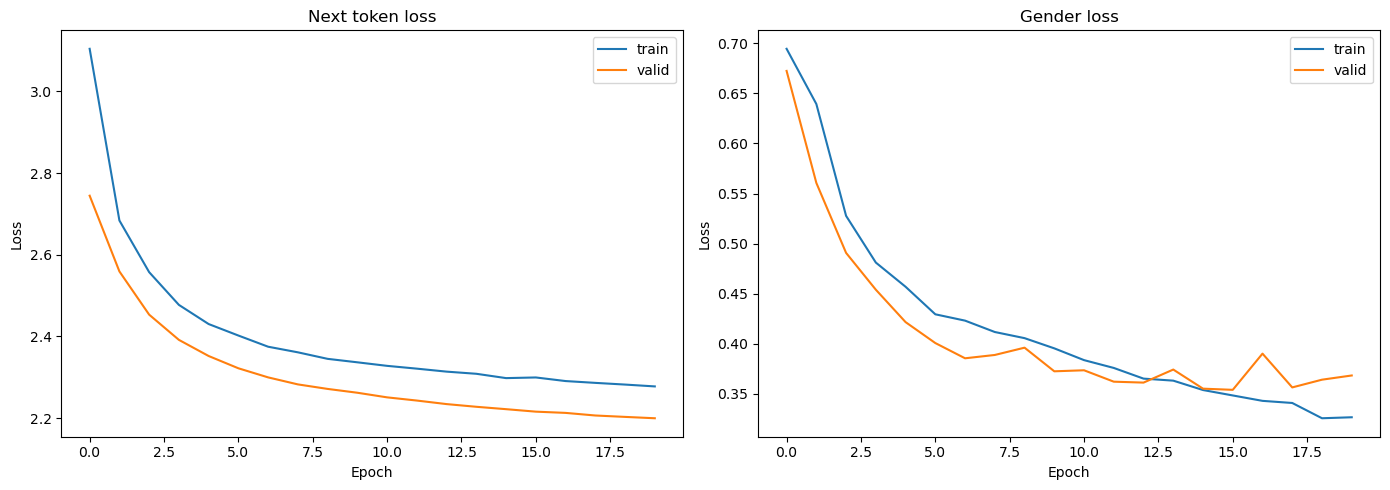

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(train_losses_next, label='train')
axes[0].plot(valid_losses_next, label='valid')
axes[0].set_title('Next token loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_losses_gender, label='train')
axes[1].plot(valid_losses_gender, label='valid')
axes[1].set_title('Gender loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [133]:
print("Generated names (multitask):")
model_multitask.eval()
for i in range(10):
    print(model_multitask.generate(temperature=1.0))

Generated names (multitask):
imhrie
fisan
niyniyh
diash
lazri
kylt
jarel
samya
cerene
karna


In [134]:
model_multitask.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for x_batch, y_batch in test_gender_loader:
        _, gender_logit = model_multitask(x_batch)
        all_logits.append(gender_logit.squeeze().cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())
all_logits = np.concatenate(all_logits)
all_labels = np.concatenate(all_labels)
auc_multitask = roc_auc_score(all_labels, all_logits)
print(f"Multitask ROC AUC on test: {auc_multitask:.4f}")

Multitask ROC AUC on test: 0.9088


## Vizualizing embeddings

Shape of embeddings: (29, 32)


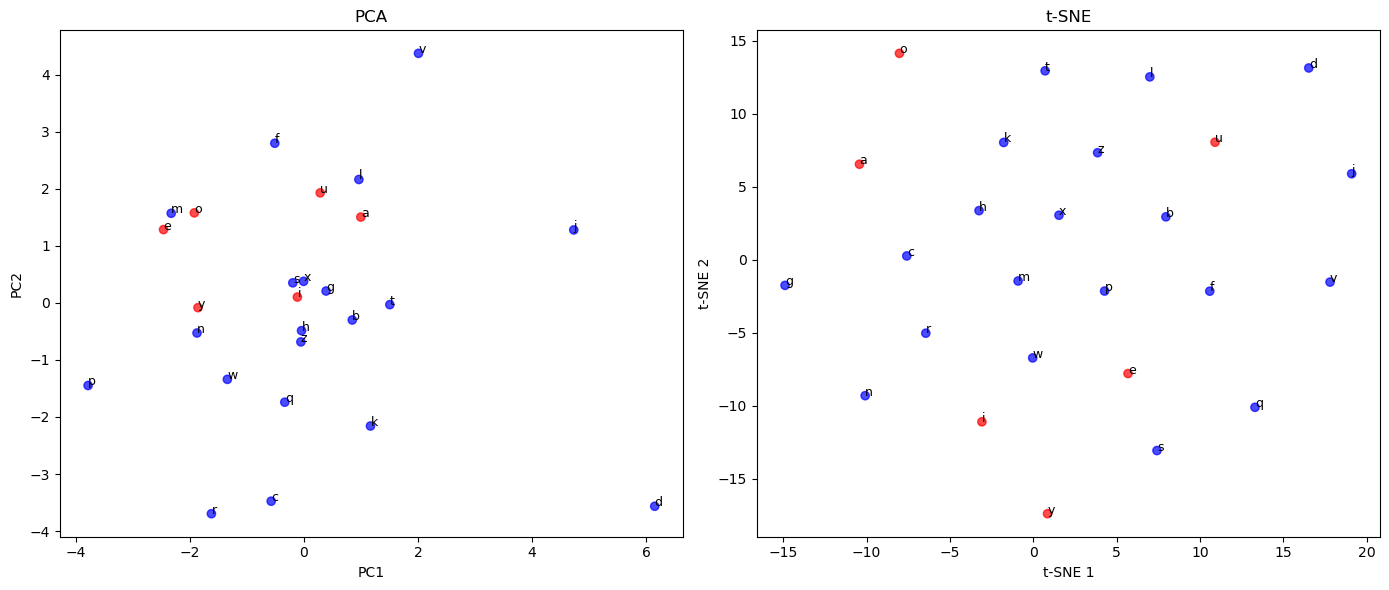

In [136]:
# Извлекаем матрицу эмбеддингов
embeddings = model_multitask.embedding.weight.detach().cpu().numpy()
print("Shape of embeddings:", embeddings.shape)

# Буквы (исключаем служебные токены)
letters = [tok for tok in tokens if tok not in ['<SOS>', '<EOS>', ' ']]
letter_indices = [token_to_id[tok] for tok in letters]
letter_embeddings = embeddings[letter_indices]

# Гласные и согласные (латиница)
vowels = set('aeiouy')
consonants = set('bcdfghjklmnpqrstvwxz')

colors = []
for ch in letters:
    if ch in vowels:
        colors.append('red')
    elif ch in consonants:
        colors.append('blue')
    else:
        colors.append('gray')

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(letter_embeddings)

# t-SNE
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Нормализация эмбеддингов (иногда помогает)
letter_emb_norm = StandardScaler().fit_transform(letter_embeddings)

tsne = TSNE(n_components=2, perplexity=15, random_state=42, init='pca')
emb_tsne = tsne.fit_transform(letter_emb_norm)

# Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].scatter(emb_pca[:,0], emb_pca[:,1], c=colors, alpha=0.7)
for i, ch in enumerate(letters):
    axes[0].annotate(ch, (emb_pca[i,0], emb_pca[i,1]), fontsize=9)
axes[0].set_title('PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(emb_tsne[:,0], emb_tsne[:,1], c=colors, alpha=0.7)
for i, ch in enumerate(letters):
    axes[1].annotate(ch, (emb_tsne[i,0], emb_tsne[i,1]), fontsize=9)
axes[1].set_title('t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()